In [1]:
%load_ext autoreload
%autoreload 2


In [2]:
import numpy as np
import pandas as pd
import tensorflow as tf
import tensorflow_probability as tfp
import arviz as az
import IPython
import altair as alt
from IPython.display import HTML
import gc
import matplotlib.pyplot as plt

from meridian.mpa.mpa_utils_meridian import MeridianMPAInput

from meridian import constants
from meridian.data import load
from meridian.data import test_utils
from meridian.model import model
from meridian.model import spec
from meridian.model import prior_distribution
from meridian.analysis import optimizer
from meridian.analysis import analyzer
from meridian.analysis import visualizer
from meridian.analysis import summarizer
from meridian.analysis import formatter

from meridian.mpa.client_config import client_config, ec50_multiplier_config, media_parameters_config


In [3]:
home_dir = '/Users/mariappan.subramanian/Library/CloudStorage/OneDrive-TheTradeDesk/MMM/Media Parameter Analysis/tmp'
client = 'Mazda'

In [4]:
main_config =  {
    # "file_path": f"{home_dir}/data/MDF_BY_GEO_Jul8_Channel_events_wit_population.csv",
    "file_path": f"{home_dir}/data/MDF_BY_GEO_EXPANDED_CLIENTS_Aug11.csv",

    # "holiday_file_path": f"{home_dir}/data/holidays_updated_apr21/holiday_effect_",

    "paid_media_imp": ["TV_I", "Display_I", "Video_I"],  # Actual CPM will be calculated based on this
    "paid_media_spends": ["TV_AC", "Display_AC", "Video_AC"],

    "paid_media_viewability_imp": ["TV_VCR", "Display_VCR", "Video_VCR"],  # viewability rate will be calculated based on this
    "paid_media_cols": ["TV_I", "Display_I", "Video_I"],  # not used

    "reach_variables": ["TV_RHH", "Display_RPP", "Video_RPP"],
    "frequency_variables": ["TV_FHH", "Display_FPP", "Video_FPP"],

    "spend_variables_for_cpm_calc": ["TV_AC", "Display_AC", "Video_AC"],  # Prior CPM will be calculated based on this
    "imp_variables_for_cpm_calc": ['TV_I', 'Display_I', 'Video_I'],  # Prior CPM will be calculated based on this

    "response_kpi": "conversions",
    "prior_config": {},
    "prior_type": "spend"
}

In [5]:
# get prior type for the coefficients (estimates)
prior_type = 'working_spend'  # "cpm_weighted_by_working_spend"
is_national = False
trans_prior_type = 'informative'

In [6]:
# ----------------------------- CREATE MODEL INPUT FILE FOR MERIDIAN --------------------------------- #
# create input object
main_config['prior_type'] = prior_type
mpa_input = MeridianMPAInput(client=client, client_config=client_config, main_config=main_config)
mdf_mw = mpa_input.mdf_mw.copy()

# write to a temp path for meridian
metrics = [mpa_input.target] + mpa_input.paid_media_imp + mpa_input.paid_media_spends
if is_national:
  # calculate pooled (geo, time level) standard deviation
  pooled_std =(mdf_mw['conversions']/mdf_mw['Population']).std()

  # national level standard deviation
  national_level_conversions = mdf_mw.groupby('WES')[['conversions']].sum().reset_index()['conversions']
  national_level_population = mdf_mw.groupby('WES')[['Population']].sum().reset_index()['Population']
  national_std = (national_level_conversions/national_level_population).std()

  correction_factor = np.round(pooled_std/national_std, 2)
  print(f"Correction factor: {correction_factor}")
  # aggregate out 'geo' field for national models
  mdf = mdf_mw. \
    groupby(['WES'])[metrics].sum(). \
      reset_index(). \
        assign(
          Region='National',
          Population=1.0,
          revenue_per_conversion=1.0
              )
else:
  correction_factor = 1.0
  mdf = mdf_mw[['WES'] + metrics + ['Region', 'Population']]. \
    reset_index(drop=True).assign(revenue_per_conversion= 1.0).copy()
  mdf.loc[:, 'WES'] = pd.to_datetime(mdf['WES']).dt.strftime('%Y-%m-%d')

# write to a temp path (input file path for meridian)
target_file_path = f"{home_dir}/trash/meridian/{client}_national_{is_national}_mdf.csv"
mdf.to_csv(target_file_path, index=False)

# ----------------------------- InputDataLoader --------------------------------- #
coord_to_columns = load.CoordToColumns(
  time='WES',
  geo='Region',
  population='Population',
  kpi='conversions',
  revenue_per_kpi='revenue_per_conversion',
  media=mpa_input.paid_media_imp,
  media_spend=mpa_input.paid_media_spends
)

ordered_chnl_names = [col.split("_")[0] for col in mpa_input.paid_media_imp]
print(f"ordered_chnl_names: {ordered_chnl_names}")
correct_media_to_channel = {col: col.split("_")[0] for col in mpa_input.paid_media_imp}
correct_media_spend_to_channel = {col: col.split("_")[0] for col in mpa_input.paid_media_spends}

# load and format input data
loader = load.CsvDataLoader(
  csv_path=target_file_path,
  kpi_type= 'non_revenue',
  coord_to_columns=coord_to_columns,
  media_to_channel=correct_media_to_channel,
  media_spend_to_channel=correct_media_spend_to_channel,
)
data = loader.load()


cost array: [69197739.76706284, 20208840.561141826, 32863319.60245556]
cpm array: [0.026279832630683553, 0.002973819213819918, 0.008836635744706934]
viewability percent [0.98683101 0.8001053  0.63033819]
working cost array: [0.6492919366289273, 0.15374247201480043, 0.19696559135627228]
prior type is working_spend and prior values are TV_AC         1.947876
Display_AC    0.461227
Video_AC      0.590897
dtype: float64
ordered_chnl_names: ['TV', 'Display', 'Video']


In [7]:
# ----------------------------- Define Prior Distribution --------------------------------- #
build_media_channel_args = data.get_paid_media_channels_argument_builder()

# a. beta_m prior (mean for the hierarchical distribution)
media_cf_prior = mpa_input.coeff_prior * correction_factor

if is_national:
  beta_m_prior_sigma = build_media_channel_args(**{chnl:val for chnl, val in zip(ordered_chnl_names, media_cf_prior)})
else:
  # hierarchical model
  allowable_deviation_percent = .1
  geometric_std = np.log(1 + allowable_deviation_percent)
  mu = np.log(0.8 * media_cf_prior) - (geometric_std ** 2 / 2)  # half-normal mean to log-normal mean
  geometric_std = np.full_like(mu, geometric_std)  # log-normal std-dev
  beta_m_prior_mu = build_media_channel_args(**{chnl:val for chnl, val in zip(ordered_chnl_names, mu)})
  beta_m_prior_sigma = build_media_channel_args(**{chnl:val for chnl, val in zip(ordered_chnl_names, geometric_std)})

# a. eta_m prior (std-dev for the hierarchical distribution)
eta_m_mu = 0.0
eta_m_mu_prior = build_media_channel_args(**{chnl:val for chnl, val in zip(ordered_chnl_names, np.repeat(eta_m_mu, len(ordered_chnl_names)))})

allowable_deviation_percent = .1
eta_m_sigma = np.log(1 + allowable_deviation_percent)
eta_m_sigma_prior = build_media_channel_args(**{chnl:val for chnl, val in zip(ordered_chnl_names, np.repeat(eta_m_sigma, len(ordered_chnl_names)))})

# b. Adstock Prior
adstock_lower_bounds = build_media_channel_args(**{chnl:media_parameters_config[chnl]['adstock_range'][0] for chnl in correct_media_to_channel.values()})
adstock_upper_bounds = build_media_channel_args(**{chnl:media_parameters_config[chnl]['adstock_range'][1] for chnl in correct_media_to_channel.values()})

# c. Half saturation Prior
ec50_mu_array = build_media_channel_args(**{chnl:np.round(ec50_multiplier_config[client][chnl], 2) for chnl in correct_media_to_channel.values()})
ec50_scale_array = np.array(ec50_mu_array) * 0.1  # roughly ±90% deviation within 3 standard deviations

# d. Slope Prior
slope_lb = build_media_channel_args(**{chnl:media_parameters_config[chnl]['slope_range'][0] for chnl in correct_media_to_channel.values()})
slope_ub = build_media_channel_args(**{chnl:media_parameters_config[chnl]['slope_range'][1] for chnl in correct_media_to_channel.values()})

# ----- define the prior distribution for the media parameters -----
eta_m=tfp.distributions.Normal(
  [float(x) for x in eta_m_mu_prior], [float(x) for x in eta_m_sigma_prior], name=constants.ETA_M)
alpha_m=tfp.distributions.Uniform([float(x) for x in adstock_lower_bounds], [float(x) for x in adstock_upper_bounds], name=constants.ALPHA_M)
ec_m=tfp.distributions.TruncatedNormal(
  loc=[float(x) for x in ec50_mu_array], scale=[float(x) for x in ec50_scale_array],
  low=[float(0.5) for _ in ec50_mu_array], high=[float(x) for x in ec50_mu_array],
  name=constants.EC_M)
slope_m=tfp.distributions.Uniform([float(x) for x in slope_lb], [float(x) for x in slope_ub], name=constants.SLOPE_M)

from meridian.model.contribution_prior_helper import create_contribution_prior
beta_dist_params = create_contribution_prior(
      channel_names=['Display', 'TV', 'Video'],
      mean_contributions={'Display': 11.5, 'TV': 30, 'Video': 15},
      confidence='high'  # or 'low' for more flexibility, 'high' for less
  )
contribution_m=tfp.distributions.Beta(
    concentration1=build_media_channel_args(**beta_dist_params['alphas']),
    concentration0=build_media_channel_args(**beta_dist_params['betas']),
    name=constants.CONTRIBUTION_M
)

eta_m = tfp.distributions.HalfNormal(0.3, name=constants.ETA_M)
prior = prior_distribution.PriorDistribution(
    # beta_m=tfp.distributions.Normal(
    #         loc=[float(x) for x in beta_m_prior_mu],
    #         scale=[float(x) for x in beta_m_prior_sigma], name=constants.BETA_M),
    contribution_m=contribution_m,
    eta_m=eta_m,
    knot_values=tfp.distributions.Normal(0.0, 1.0, name=constants.KNOT_VALUES),
    tau_g_excl_baseline=tfp.distributions.Normal(0.0, 1.0, name=constants.TAU_G_EXCL_BASELINE)
    # alpha_m=alpha_m,
    # ec_m=ec_m,
    # slope_m=slope_m
)

means: [0.115 0.3   0.15 ]
stds: [0.00575 0.015   0.0075 ]
Channel Display: mean=11.50%, std=0.58%
Channel TV: mean=30.00%, std=1.50%
Channel Video: mean=15.00%, std=0.75%
Contribution Prior Configuration: high
Display   : mean= 11.5%, std= 0.6%, Beta(α=353.88, β=2723.38)
TV        : mean= 30.0%, std= 1.5%, Beta(α=279.70, β=652.63)
Video     : mean= 15.0%, std= 0.8%, Beta(α=339.85, β=1925.82)

Total expected contribution: 56.5%


In [9]:
# -------------------------- Prior Feasibility Check --------------------------------- #
from meridian.model import prior_feasibility
model_spec = spec.ModelSpec(prior=prior, media_prior_type='contribution', media_effects_dist='log_normal')
mmm = model.Meridian(input_data=data, model_spec=model_spec)

# Check feasibility
checker = prior_feasibility.PriorFeasibilityChecker(mmm)
report = checker.check_contribution_feasibility(
    n_draws=2000,
    include_sensitivity=True,
    seed=42
)

print(report)

I0000 00:00:1759633851.195598 5063647 service.cc:148] XLA service 0x16e91eea0 initialized for platform Host (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1759633851.195629 5063647 service.cc:156]   StreamExecutor device (0): Host, Default Version
I0000 00:00:1759633851.201848 5063647 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: name node, decay_function, outside of any statement?
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: name node, decay_function, outside of any statement?
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert


2025-10-04 22:10:51.860950: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
/Users/mariappan.subramanian/Documents/repo/forked/meridian/.venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/Users/mariappan.subramanian/Documents/repo/forked/meridian/.venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


PRIOR FEASIBILITY REPORT

Based on 2000 prior draws

CONTRIBUTION % COMPARISON: Target vs Realized Prior
--------------------------------------------------------------------------------
channel  target_mean_pct  target_std_pct  realized_mean_pct  realized_std_pct  deviation_pct
     TV        30.000109        1.500004          20.525660          1.680400      -9.474449
Display        11.499842        0.574997           7.857754          0.661728      -3.642088
  Video        14.999978        0.749999          10.251605          0.851158      -4.748373

PARAMETER SENSITIVITY ANALYSIS
--------------------------------------------------------------------------------
channel parameter  correlation  variance_explained_pct
Display     eta_m     0.031122                0.096856
Display   alpha_m     0.016956                0.028752
Display      ec_m    -0.002946                0.000868
Display   slope_m          NaN                     NaN
     TV      ec_m     0.031700                0.100490

In [17]:
checker.identify_compatible_regions(channel='TV', target_contribution_pct=30.0, tolerance_pct=5.0)

{'alpha_m': (0.13702011108398438, 0.9135348796844482),
 'ec_m': (0.10371656715869904, 2.0795705318450928),
 'slope_m': (1.0, 1.0),
 'eta_m': (0.0004951431765221059, 0.622904896736145)}

In [62]:
model_spec = spec.ModelSpec(prior=prior, media_prior_type='contribution', media_effects_dist='log_normal')
mmm = model.Meridian(input_data=data, model_spec=model_spec)

# draw samples from the prior distribution
mmm.sample_prior(5000)
prior_samples = mmm.inference_data.prior

# calculate expected response for each sample
mmm_analyzer = analyzer.Analyzer(mmm)
prior_predictive_total_outcome = mmm_analyzer.expected_outcome(use_posterior=False)
prior_predictive_incremental_outcome = mmm_analyzer.incremental_outcome(use_posterior=False)
prior_predictive_contribution_percentage = prior_predictive_incremental_outcome / prior_predictive_total_outcome[..., None]

In [63]:
tf.reduce_mean(prior_predictive_contribution_percentage, axis=(0, 1))


<tf.Tensor: shape=(3,), dtype=float32, numpy=array([0.2053792 , 0.07879876, 0.10274915], dtype=float32)>

In [64]:
tf.math.reduce_std(prior_predictive_contribution_percentage, axis=(0, 1))

<tf.Tensor: shape=(3,), dtype=float32, numpy=array([0.01668129, 0.0066172 , 0.00851792], dtype=float32)>

In [65]:
tf.reduce_min(prior_predictive_contribution_percentage, axis=(0, 1)), tf.reduce_max(prior_predictive_contribution_percentage, axis=(0, 1))

(<tf.Tensor: shape=(3,), dtype=float32, numpy=array([0.15687364, 0.05969065, 0.07853806], dtype=float32)>,
 <tf.Tensor: shape=(3,), dtype=float32, numpy=array([0.28462374, 0.1089412 , 0.14871736], dtype=float32)>)

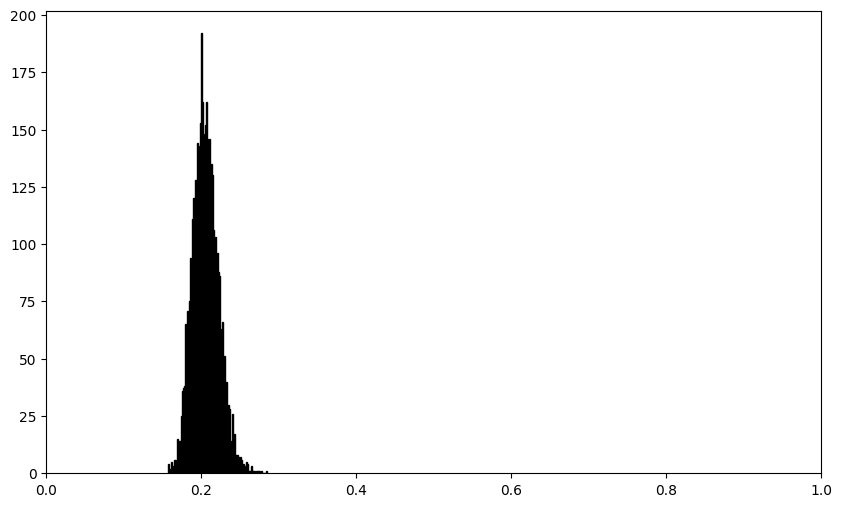

In [66]:
import seaborn as sns
contrib_pct_samples = prior_predictive_contribution_percentage[...,0].numpy().flatten()
fig, ax = plt.subplots(figsize=(10, 6))
plt.hist(contrib_pct_samples, bins=100, edgecolor='black');
ax.set_xlim(0, 1)
plt.show()


In [60]:
contrib_pct_samples.mean(), contrib_pct_samples.std(), contrib_pct_samples.min(), contrib_pct_samples.max()

(np.float32(0.26307514),
 np.float32(1.4427302),
 np.float32(-11.207311),
 np.float32(98.54176))

In [26]:
prior_samples

<xarray.Dataset> Size: 6MB
Dimensions:         (chain: 1, draw: 5000, media_channel: 3, geo: 36,
                     knots: 78, time: 78)
Coordinates:
  * chain           (chain) int64 8B 0
  * draw            (draw) int64 40kB 0 1 2 3 4 5 ... 4995 4996 4997 4998 4999
  * media_channel   (media_channel) object 24B 'TV' 'Display' 'Video'
  * geo             (geo) <U14 2kB 'ALABAMA' 'ARIZONA' ... 'WISCONSIN'
  * knots           (knots) int64 624B 0 1 2 3 4 5 6 7 ... 71 72 73 74 75 76 77
  * time            (time) object 624B '2024-01-06' ... '2025-06-28'
Data variables:
    alpha_m         (chain, draw, media_channel) float32 60kB 0.7622 ... 0.3226
    beta_gm         (chain, draw, geo, media_channel) float32 2MB 0.9421 ... ...
    beta_m          (chain, draw, media_channel) float32 60kB -0.1981 ... -0....
    contribution_m  (chain, draw, media_channel) float32 60kB 0.2982 ... 0.1596
    ec_m            (chain, draw, media_channel) float32 60kB 0.2394 ... 0.414
    eta_m           (chain, draw, media_channel) float32 60kB 0.2186 ... 0.1513
    knot_values     (chain, draw, knots) float32 2MB -0.7237 0.4259 ... 1.387
    mu_t            (chain, draw, time) float32 2MB -0.7237 0.4259 ... 1.387
    sigma           (chain, draw) float32 20kB 0.7701 6.819 ... 1.531 9.169
    slope_m         (chain, draw, media_channel) float32 60kB 1.0 1.0 ... 1.0
    tau_g           (chain, draw, geo) float32 720kB -0.1878 -0.2703 ... 0.5155
Attributes:
    created_at:     2025-10-05T03:37:41.294096+00:00
    arviz_version:  0.22.0

In [28]:
prior_predictive_samples.shape

TensorShape([1, 5000])

In [29]:
prior_predictive_incremental_outcome.shape

TensorShape([1, 5000, 3])